<a href="https://colab.research.google.com/github/KP-365/Natural_Gas_Pricing/blob/main/storage_volatility_final_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Gas Storage Forecasting: Baseline vs. Bayesian vs. Heteroscedastic NN

Compares three models for weekly U.S. natural gas storage-change forecasting:
1. **Baseline**: OLS regression (point estimate only)
2. **Bayesian regression**: PyMC, full posterior predictive distribution
3. **Heteroscedastic neural network**: PyTorch, predicts mean AND variance

Each is evaluated on RMSE (accuracy) and calibration/coverage (is the stated
uncertainty trustworthy). The final section tests whether each model's
predicted uncertainty correlates with realised Henry Hub price volatility.

**Requires a free EIA API key** (get one instantly at eia.gov/opendata/register.php) --
this notebook runs entirely on live EIA and NOAA data, no synthetic fallback.
Get a free key at: https://www.eia.gov/opendata/register.php


In [1]:
import re
import os
import numpy as np
import pandas as pd
from scipy import stats
import requests
import matplotlib.pyplot as plt

# --- Configuration ---
MONTHS_BACK = 72
EIA_API_KEY = "lCNrpiQugnNaUoJ1kOelcXsXCFt748mrv2l3yOpo"
if not EIA_API_KEY:
    raise RuntimeError("Set EIA_API_KEY (env var, or paste it directly above) before running this notebook.")

CPC_HEATING_URL = "https://ftp.cpc.ncep.noaa.gov/htdocs/degree_days/weighted/legacy_files/heating/statesCONUS/{year}/weekly-{yyyymmdd}.txt"
CPC_COOLING_URL = "https://ftp.cpc.ncep.noaa.gov/htdocs/degree_days/weighted/legacy_files/cooling/statesCONUS/{year}/weekly-{yyyymmdd}.txt"

EIA_STORAGE_URL = "https://api.eia.gov/v2/natural-gas/stor/wkly/data/"
EIA_STORAGE_PARAMS = {
    "frequency": "weekly", "data[0]": "value",
    "sort[0][column]": "period", "sort[0][direction]": "asc",
    "offset": 0, "length": 5000,
}
EIA_PRICE_URL = "https://api.eia.gov/v2/natural-gas/pri/fut/data/"
EIA_PRICE_PARAMS = {
    "frequency": "daily", "data[0]": "value",
    "sort[0][column]": "period", "sort[0][direction]": "asc",
    "offset": 0, "length": 5000,
}


## STAGE 1: Data ingestion

Fetch functions for EIA (storage level, price, capacity) and NOAA CPC (HDD/CDD).

In [2]:
def fetch_eia_storage(api_key, start=None, end=None):
    """Weekly Lower-48 storage LEVEL (Bcf) via EIA v2.
    Uses a server-side facet filter (facets[duoarea][]=R48) rather than
    filtering after the fact -- the raw stor/wkly route returns all six
    regions (R48 national total plus five sub-regions) for every week, so
    without this filter the length=5000 row cap is hit roughly 6x sooner
    than expected, silently truncating the series years earlier than the
    requested end date."""
    params = dict(EIA_STORAGE_PARAMS); params["api_key"] = api_key
    params["facets[duoarea][]"] = "R48"
    if start: params["start"] = start
    if end: params["end"] = end
    resp = requests.get(EIA_STORAGE_URL, params=params, timeout=30); resp.raise_for_status()
    df = pd.DataFrame(resp.json()["response"]["data"])
    df["period"] = pd.to_datetime(df["period"])
    df = df[df["duoarea"] == "R48"].sort_values("period").set_index("period")
    return df["value"].astype(float)


def fetch_eia_price(api_key, start=None, end=None):
    """Daily Henry Hub spot price via EIA v2.
    Uses a server-side facet filter (facets[series][]=RNGWHHD) rather than
    filtering after the fact -- the pri/fut route returns every futures
    contract series per day, so without this filter the length=5000 row cap
    exhausts after only ~4 years of calendar time instead of the full range."""
    params = dict(EIA_PRICE_PARAMS); params["api_key"] = api_key
    params["facets[series][]"] = "RNGWHHD"
    if start: params["start"] = start
    if end: params["end"] = end
    resp = requests.get(EIA_PRICE_URL, params=params, timeout=30); resp.raise_for_status()
    df = pd.DataFrame(resp.json()["response"]["data"])
    df["period"] = pd.to_datetime(df["period"])
    df = df[df["series"] == "RNGWHHD"].sort_values("period").set_index("period")
    return df["value"].astype(float)


def fetch_eia_capacity(api_key):
    """EIA published U.S. Lower-48 working gas capacity (Bcf), with a fallback."""
    try:
        params = {"api_key": api_key, "frequency": "annual", "data[0]": "value",
                   "sort[0][column]": "period", "sort[0][direction]": "desc",
                   "offset": 0, "length": 20}
        resp = requests.get("https://api.eia.gov/v2/natural-gas/stor/cap/data/", params=params, timeout=30)
        resp.raise_for_status()
        df = pd.DataFrame(resp.json()["response"]["data"])
        df = df[df["duoarea"] == "R48"]
        return float(df.sort_values("period")["value"].iloc[-1]) if not df.empty else 4300.0
    except Exception as e:
        print(f"Capacity fetch failed ({e}); using fallback 4300 Bcf.")
        return 4300.0


def fetch_cpc_national_degree_days(date, kind="heating"):
    url_tmpl = CPC_HEATING_URL if kind == "heating" else CPC_COOLING_URL
    url = url_tmpl.format(year=date.year, yyyymmdd=date.strftime("%Y%m%d"))
    resp = requests.get(url, timeout=20); resp.raise_for_status()
    m = re.search(r"POPULATION WEIGHTED\s+REGION.*?UNITED STATES\s+(\d+)", resp.text, re.S)
    if not m: raise ValueError(f"parse failed for {url}")
    return float(m.group(1))


def get_real_hdd_cdd(weeks_index):
    hdd, cdd = [], []
    for d in weeks_index:
        try: hdd.append(fetch_cpc_national_degree_days(d, "heating"))
        except Exception: hdd.append(np.nan)
        try: cdd.append(fetch_cpc_national_degree_days(d, "cooling"))
        except Exception: cdd.append(np.nan)
    return np.array(hdd), np.array(cdd)


def get_real_data(months_back, api_key):
    """Returns weekly storage CHANGE, price, HDD, CDD, storage-fraction-of-capacity (no look-ahead)."""
    if not api_key:
        raise RuntimeError("Set EIA_API_KEY first.")
    end = pd.Timestamp.today(); start = end - pd.DateOffset(months=months_back)
    s, e = start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d")
    storage_level = fetch_eia_storage(api_key, s, e)
    price = fetch_eia_price(api_key, s, e)
    capacity = fetch_eia_capacity(api_key)
    storage_change = storage_level.diff().dropna()
    storage_fraction = (storage_level / capacity).shift(1).reindex(storage_change.index)
    hdd, cdd = get_real_hdd_cdd(storage_change.index)
    return storage_change, price, hdd, cdd, storage_fraction


## STAGE 1 (cont.): Load data + chronological train/validation/test split

Weekly change is derived by differencing the level series. Split is chronological (no shuffling), since this is time series data.

In [3]:
storage, price, hdd, cdd, storage_fraction = get_real_data(MONTHS_BACK, EIA_API_KEY)
print(f"Loaded {len(storage)} real weekly storage-change observations.")

hdd = np.asarray(hdd)[-len(storage):]
cdd = np.asarray(cdd)[-len(storage):]
storage_fraction = pd.Series(storage_fraction).reindex(storage.index).ffill().bfill().values

# NOAA CPC's legacy archive has occasional missing weekly files (a handful
# out of a few hundred, not a bug). Drop those rows rather than let NaNs
# propagate into the regression, since np.linalg.lstsq fails opaquely on NaNs.
nan_mask = np.isnan(hdd) | np.isnan(cdd)
if nan_mask.any():
    missing_weeks = list(storage.index[nan_mask])
    print(f"Dropping {nan_mask.sum()} weeks with missing NOAA CPC data: {missing_weeks}")
    storage = storage[~nan_mask]
    hdd = hdd[~nan_mask]
    cdd = cdd[~nan_mask]
    storage_fraction = storage_fraction[~nan_mask]

n = len(storage)
train_end = int(n * 0.77)   # ~80/104 weeks
val_end = int(n * 0.87)     # ~10 more weeks
# remainder (~13%, 10-15 weeks) is the held-out test set

X_all = np.column_stack([np.ones(n), hdd, cdd, storage_fraction])
y_all = storage.values

X_train, y_train = X_all[:train_end], y_all[:train_end]
X_val, y_val = X_all[train_end:val_end], y_all[train_end:val_end]
X_test, y_test = X_all[val_end:], y_all[val_end:]

print(f"Train: {len(X_train)} weeks | Val: {len(X_val)} weeks | Test: {len(X_test)} weeks")

Loaded 311 real weekly storage-change observations.
Dropping 5 weeks with missing NOAA CPC data: [Timestamp('2023-09-29 00:00:00'), Timestamp('2023-12-08 00:00:00'), Timestamp('2024-01-26 00:00:00'), Timestamp('2024-02-09 00:00:00'), Timestamp('2024-03-01 00:00:00')]
Train: 235 weeks | Val: 31 weeks | Test: 40 weeks


## STAGE 2a: Baseline model (OLS)

The point-accuracy bar the other two models need to clear.

ŷᵢ = β0 + β1·HDDᵢ + β2·CDDᵢ + β3·(Sᵢ/C) + εᵢ

In [4]:
beta, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)
y_pred_baseline = X_test @ beta
rmse_baseline = np.sqrt(np.mean((y_test - y_pred_baseline) ** 2))
print(f"Baseline OLS test RMSE: {rmse_baseline:.2f} Bcf")
print(f"Coefficients -- Intercept: {beta[0]:.2f}  HDD: {beta[1]:.3f}  CDD: {beta[2]:.3f}  Storage-frac: {beta[3]:.3f}")

Baseline OLS test RMSE: 19.12 Bcf
Coefficients -- Intercept: 217.01  HDD: -1.927  CDD: -2.248  Storage-frac: -17.130


## STAGE 2b: Bayesian regression (PyMC)

Same predictors, but places priors over the coefficients and returns a full
posterior predictive distribution instead of one number, giving a genuine
90% credible interval for every forecast.

In [5]:
import pymc as pm

X_train_std = X_train.copy()
# standardise HDD/CDD/storage_fraction columns (not the intercept) for easier sampling
col_means = X_train[:, 1:].mean(axis=0)
col_stds = X_train[:, 1:].std(axis=0)
col_stds[col_stds == 0] = 1.0

def standardise(X):
    Xs = X.copy()
    Xs[:, 1:] = (X[:, 1:] - col_means) / col_stds
    return Xs

X_train_s = standardise(X_train)
X_test_s = standardise(X_test)

with pm.Model() as bayes_model:
    intercept = pm.Normal("intercept", mu=0, sigma=50)
    coefs = pm.Normal("coefs", mu=0, sigma=20, shape=3)
    sigma = pm.HalfNormal("sigma", sigma=20)

    mu = intercept + pm.math.dot(X_train_s[:, 1:], coefs)
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train)

    trace = pm.sample(1000, tune=1000, chains=2, cores=1, progressbar=False, random_seed=7)

print("Bayesian regression sampled.")
print(pm.summary(trace, var_names=["intercept", "coefs", "sigma"]).round(2))

Bayesian regression sampled.
             mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept   -5.93  1.43   -8.52    -3.15       0.03     0.03    2232.0   
coefs[0]  -137.45  2.37 -142.11  -133.18       0.06     0.05    1695.0   
coefs[1]   -62.95  2.40  -67.70   -58.75       0.06     0.06    1729.0   
coefs[2]    -2.84  1.47   -5.68    -0.08       0.03     0.03    2122.0   
sigma       22.01  1.03   20.19    24.03       0.02     0.02    1958.0   

           ess_tail  r_hat  
intercept    1438.0    1.0  
coefs[0]     1225.0    1.0  
coefs[1]     1345.0    1.0  
coefs[2]     1360.0    1.0  
sigma        1506.0    1.0  


In [6]:
# Posterior predictive on the test set
with bayes_model:
    intercept_samples = trace.posterior["intercept"].values.reshape(-1)
    coef_samples = trace.posterior["coefs"].values.reshape(-1, 3)
    sigma_samples = trace.posterior["sigma"].values.reshape(-1)

n_draws = len(intercept_samples)
mu_test = intercept_samples[:, None] + coef_samples @ X_test_s[:, 1:].T   # (n_draws, n_test)

bayes_mean = mu_test.mean(axis=0)
bayes_lower = np.percentile(mu_test, 5, axis=0)
bayes_upper = np.percentile(mu_test, 95, axis=0)

rmse_bayes = np.sqrt(np.mean((y_test - bayes_mean) ** 2))
coverage_bayes = np.mean((y_test >= bayes_lower) & (y_test <= bayes_upper))

print(f"Bayesian regression test RMSE: {rmse_bayes:.2f} Bcf")
print(f"Bayesian 90% interval empirical coverage: {coverage_bayes:.2%} (target ~90%)")

Bayesian regression test RMSE: 19.53 Bcf
Bayesian 90% interval empirical coverage: 12.50% (target ~90%)


## STAGE 2c: Heteroscedastic neural network (PyTorch)

A small two-headed network predicting both a mean μ(x) and variance σ²(x),
trained by minimising the Gaussian negative log-likelihood (Nix and Weigend, 1994):

L = (1/N) Σᵢ [ (yᵢ − μ(xᵢ))² / σ²(xᵢ) + log σ²(xᵢ) ]

In [7]:
import torch
import torch.nn as nn

torch.manual_seed(7)

class HeteroscedasticNN(nn.Module):
    def __init__(self, n_features, hidden=16):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(n_features, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden, 1)
        self.logvar_head = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.shared(x)
        mean = self.mean_head(h).squeeze(-1)
        logvar = self.logvar_head(h).squeeze(-1)
        return mean, logvar


def gaussian_nll_loss(y, mean, logvar):
    var = torch.exp(logvar)
    return torch.mean((y - mean) ** 2 / var + logvar)


# Use the same standardised features as the Bayesian model (excluding intercept column)
Xtr_t = torch.tensor(X_train_s[:, 1:], dtype=torch.float32)
ytr_t = torch.tensor(y_train, dtype=torch.float32)
Xte_t = torch.tensor(X_test_s[:, 1:], dtype=torch.float32)

nn_model = HeteroscedasticNN(n_features=Xtr_t.shape[1])
optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.01)

n_epochs = 500
for epoch in range(n_epochs):
    optimizer.zero_grad()
    mean_pred, logvar_pred = nn_model(Xtr_t)
    loss = gaussian_nll_loss(ytr_t, mean_pred, logvar_pred)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}  NLL loss: {loss.item():.3f}")

nn_model.eval()
with torch.no_grad():
    mean_test, logvar_test = nn_model(Xte_t)
    mean_test = mean_test.numpy()
    std_test = np.sqrt(np.exp(logvar_test.numpy()))

nn_lower = mean_test - 1.645 * std_test
nn_upper = mean_test + 1.645 * std_test

rmse_nn = np.sqrt(np.mean((y_test - mean_test) ** 2))
coverage_nn = np.mean((y_test >= nn_lower) & (y_test <= nn_upper))

print(f"\nHeteroscedastic NN test RMSE: {rmse_nn:.2f} Bcf")
print(f"Heteroscedastic NN 90% interval empirical coverage: {coverage_nn:.2%} (target ~90%)")

Epoch 100/500  NLL loss: 11.328
Epoch 200/500  NLL loss: 10.900
Epoch 300/500  NLL loss: 10.630
Epoch 400/500  NLL loss: 10.408
Epoch 500/500  NLL loss: 10.222

Heteroscedastic NN test RMSE: 114.86 Bcf
Heteroscedastic NN 90% interval empirical coverage: 87.50% (target ~90%)


## STAGE 2 (summary): Compare all three models on the held-out test set

(Note: this uses the single chronological test split from Stage 1, before the full walk-forward backtest in Stage 5 below.)

              Model  RMSE (Bcf)              90% Coverage
     Baseline (OLS)   19.123634 n/a (point estimate only)
Bayesian regression   19.527158                     12.5%
 Heteroscedastic NN  114.856819                     87.5%


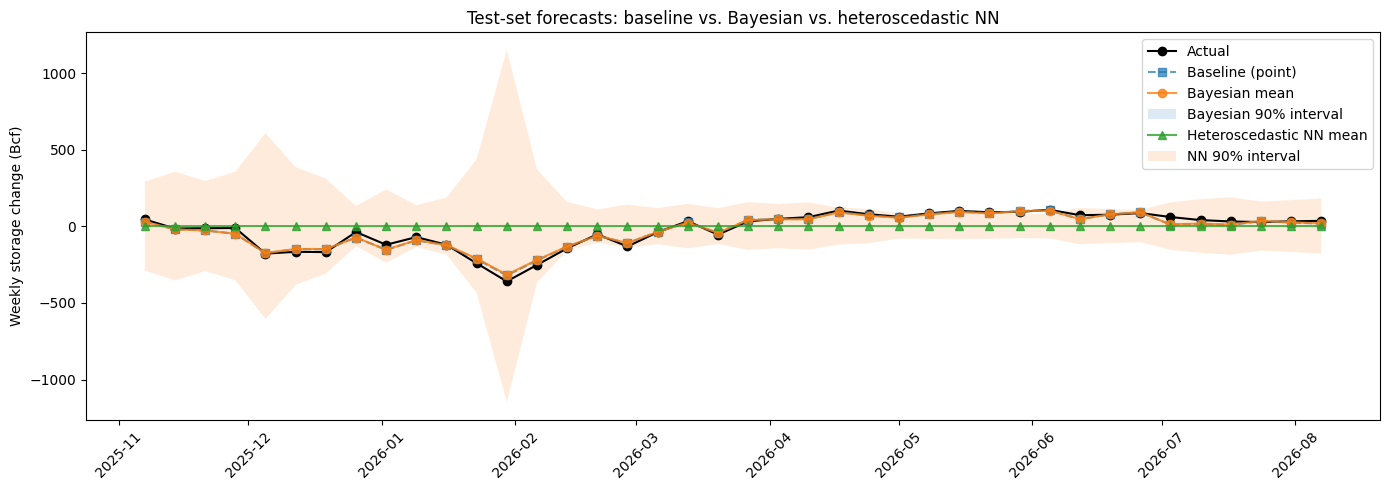

In [8]:
results = pd.DataFrame({
    "Model": ["Baseline (OLS)", "Bayesian regression", "Heteroscedastic NN"],
    "RMSE (Bcf)": [rmse_baseline, rmse_bayes, rmse_nn],
    "90% Coverage": [np.nan, coverage_bayes, coverage_nn],
})
results["90% Coverage"] = results["90% Coverage"].apply(lambda x: f"{x:.1%}" if pd.notnull(x) else "n/a (point estimate only)")
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
test_dates = storage.index[val_end:]
ax.plot(test_dates, y_test, "ko-", label="Actual", linewidth=1.5)
ax.plot(test_dates, y_pred_baseline, "s--", label="Baseline (point)", alpha=0.7)
ax.plot(test_dates, bayes_mean, "o-", label="Bayesian mean", alpha=0.8)
ax.fill_between(test_dates, bayes_lower, bayes_upper, alpha=0.15, label="Bayesian 90% interval")
ax.plot(test_dates, mean_test, "^-", label="Heteroscedastic NN mean", alpha=0.8)
ax.fill_between(test_dates, nn_lower, nn_upper, alpha=0.15, label="NN 90% interval")
ax.set_ylabel("Weekly storage change (Bcf)")
ax.set_title("Test-set forecasts: baseline vs. Bayesian vs. heteroscedastic NN")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## STAGE 3: Volatility validation (initial check, single test split)

Does predicted interval width precede realised price volatility? Price is used ONLY here, never as a model input. This is a quick check on the Stage 1 test split -- the walk-forward backtest (Stage 5) below gives the fuller, many-week version.

In [9]:
def realised_volatility(price, start, days=6):
    window = price[(price.index > start) & (price.index <= start + pd.Timedelta(days=days))]
    if len(window) < 2:
        return np.nan
    return window.diff().dropna().std()

test_dates = storage.index[val_end:]
realised_vol = pd.Series({t: realised_volatility(price, t) for t in test_dates})

bayes_width = pd.Series(bayes_upper - bayes_lower, index=test_dates)
nn_width = pd.Series(nn_upper - nn_lower, index=test_dates)

for name, width in [("Bayesian regression", bayes_width), ("Heteroscedastic NN", nn_width)]:
    df = pd.DataFrame({"width": width, "vol": realised_vol}).dropna()
    if len(df) >= 2:
        corr, pval = stats.pearsonr(df["width"], df["vol"])
        print(f"{name}: predicted interval width vs. realised volatility -> r={corr:.3f}, p={pval:.3f}")
    else:
        print(f"{name}: not enough paired observations to test ({len(df)} rows).")

Bayesian regression: predicted interval width vs. realised volatility -> r=0.340, p=0.034
Heteroscedastic NN: predicted interval width vs. realised volatility -> r=0.481, p=0.002


## STAGE 4: CRPS

A single strictly-proper score combining accuracy and calibration (Gneiting and Raftery, 2007), computed on the Stage 1 test split.

In [10]:
def gaussian_crps(y_true, mean, std):
    """Closed-form CRPS for a Gaussian predictive distribution (Gneiting and Raftery, 2007)."""
    std = np.maximum(std, 1e-8)
    z = (y_true - mean) / std
    phi = stats.norm.pdf(z)
    Phi = stats.norm.cdf(z)
    return std * (z * (2 * Phi - 1) + 2 * phi - 1 / np.sqrt(np.pi))

bayes_std = (bayes_upper - bayes_lower) / (2 * 1.645)
nn_std = std_test

crps_bayes = gaussian_crps(y_test, bayes_mean, bayes_std).mean()
crps_nn = gaussian_crps(y_test, mean_test, nn_std).mean()

print(f"Bayesian regression mean CRPS: {crps_bayes:.2f} Bcf")
print(f"Heteroscedastic NN mean CRPS:  {crps_nn:.2f} Bcf")
print("(lower is better -- CRPS rewards both accuracy and appropriately-sized uncertainty)")

Bayesian regression mean CRPS: 13.86 Bcf
Heteroscedastic NN mean CRPS:  61.75 Bcf
(lower is better -- CRPS rewards both accuracy and appropriately-sized uncertainty)


## STAGE 5: Walk-forward (rolling-origin) backtest

The proper many-week backtest referenced in the proposal -- this is the "Stage 3" box in the architecture diagram, run in full here.

Refits each model at every step using only data available up to that point,
forecasting one week ahead, then advancing the window. This is the proper
time-series validation described in the proposal, evaluating across many
out-of-sample weeks rather than a single static split.

To keep runtime practical, the Bayesian model uses a closed-form conjugate
linear-Gaussian update (mathematically a Bayesian linear regression, just
without MCMC sampling at every step) and the NN is warm-started (continues
training from its previous weights with fewer epochs) rather than trained
from scratch each week.

In [11]:
def bayesian_linear_closed_form(X, y, prior_mean=None, prior_cov=None, noise_var=None):
    """Closed-form Bayesian linear regression posterior (conjugate Normal prior).
    Returns posterior mean, posterior covariance, and estimated noise variance."""
    n_features = X.shape[1]
    if prior_mean is None:
        prior_mean = np.zeros(n_features)
    if prior_cov is None:
        prior_cov = np.eye(n_features) * 400  # weakly informative
    if noise_var is None:
        noise_var = max(np.var(y), 1.0)

    prior_precision = np.linalg.inv(prior_cov)
    post_precision = prior_precision + (X.T @ X) / noise_var
    post_cov = np.linalg.inv(post_precision)
    post_mean = post_cov @ (prior_precision @ prior_mean + X.T @ y / noise_var)
    return post_mean, post_cov, noise_var


def walk_forward_backtest(X_all, y_all, dates, min_train=60, nn_refit_every=4, nn_epochs_refit=50):
    """Expanding-window backtest for baseline, Bayesian, and heteroscedastic NN."""
    n = len(y_all)
    records = []

    # Warm-started NN: initialise once, then keep refining
    wf_nn = HeteroscedasticNN(n_features=X_all.shape[1] - 1)
    wf_optimizer = torch.optim.Adam(wf_nn.parameters(), lr=0.01)

    for t in range(min_train, n - 1):
        X_train_t, y_train_t = X_all[:t], y_all[:t]
        X_next, y_next = X_all[t:t+1], y_all[t]

        # --- Baseline ---
        beta_t, *_ = np.linalg.lstsq(X_train_t, y_train_t, rcond=None)
        pred_baseline = (X_next @ beta_t).item()

        # --- Bayesian (closed-form) ---
        cm = X_train_t[:, 1:].mean(axis=0)
        cs = X_train_t[:, 1:].std(axis=0); cs[cs == 0] = 1.0
        Xtr_s = (X_train_t[:, 1:] - cm) / cs
        Xnext_s = (X_next[:, 1:] - cm) / cs
        post_mean, post_cov, noise_var = bayesian_linear_closed_form(Xtr_s, y_train_t)
        pred_bayes_mean = (Xnext_s @ post_mean).item()
        pred_var = (Xnext_s @ post_cov @ Xnext_s.T).item() + noise_var
        pred_bayes_std = np.sqrt(pred_var)

        # --- Heteroscedastic NN (warm-started, light refit every few steps) ---
        if (t - min_train) % nn_refit_every == 0:
            Xtr_nn = torch.tensor(Xtr_s, dtype=torch.float32)
            ytr_nn = torch.tensor(y_train_t, dtype=torch.float32)
            wf_nn.train()
            for _ in range(nn_epochs_refit):
                wf_optimizer.zero_grad()
                m, lv = wf_nn(Xtr_nn)
                l = gaussian_nll_loss(ytr_nn, m, lv)
                l.backward()
                wf_optimizer.step()
        wf_nn.eval()
        with torch.no_grad():
            m_next, lv_next = wf_nn(torch.tensor(Xnext_s, dtype=torch.float32))
        pred_nn_mean = float(m_next.item())
        pred_nn_std = float(np.sqrt(np.exp(lv_next.item())))

        records.append({
            "date": dates[t], "actual": y_next,
            "baseline_pred": pred_baseline,
            "bayes_mean": pred_bayes_mean, "bayes_std": pred_bayes_std,
            "nn_mean": pred_nn_mean, "nn_std": pred_nn_std,
        })

    return pd.DataFrame(records).set_index("date")


print("Running walk-forward backtest (this may take a minute)...")
# min_train is a FIXED number of weeks, not tied to the train/val/test split above --
# using train_end here would restrict the backtest to only the last ~20% of the loaded
# history (e.g. ~2 years even with 8 years loaded). A fixed, smaller starting point lets
# the backtest cover most of the available data.
MIN_TRAIN_WEEKS = 80
wf_results = walk_forward_backtest(X_all, y_all, storage.index, min_train=MIN_TRAIN_WEEKS)
print(f"Backtested {len(wf_results)} out-of-sample weeks "
      f"(from week {MIN_TRAIN_WEEKS} to {len(storage)-1} of {len(storage)} total weeks loaded).")
wf_results.head()

Running walk-forward backtest (this may take a minute)...
Backtested 225 out-of-sample weeks (from week 80 to 305 of 306 total weeks loaded).


,actual,baseline_pred,bayes_mean,bayes_std,nn_mean,nn_std
date,,,,,,
2022-03-11,-79.0,-81.908062,-53.034878,107.872520,-1.261206,243.948075
2022-03-18,-51.0,-34.049201,-33.999858,107.555518,-1.178677,265.818879
2022-03-25,26.0,17.090990,-4.650636,107.038429,-1.035309,214.831699
2022-04-01,-33.0,-44.828962,-32.178793,106.108336,-1.165146,213.455444
2022-04-08,15.0,-1.940118,-4.091528,105.423092,-0.990797,208.283193


In [12]:
# Walk-forward evaluation: RMSE, coverage, CRPS for all three models across every backtested week
def summarise_walk_forward(df):
    out = {}
    out["Baseline RMSE"] = np.sqrt(np.mean((df["actual"] - df["baseline_pred"]) ** 2))
    out["Bayesian RMSE"] = np.sqrt(np.mean((df["actual"] - df["bayes_mean"]) ** 2))
    out["NN RMSE"] = np.sqrt(np.mean((df["actual"] - df["nn_mean"]) ** 2))

    bayes_lo = df["bayes_mean"] - 1.645 * df["bayes_std"]
    bayes_hi = df["bayes_mean"] + 1.645 * df["bayes_std"]
    nn_lo = df["nn_mean"] - 1.645 * df["nn_std"]
    nn_hi = df["nn_mean"] + 1.645 * df["nn_std"]

    out["Bayesian 90% coverage"] = np.mean((df["actual"] >= bayes_lo) & (df["actual"] <= bayes_hi))
    out["NN 90% coverage"] = np.mean((df["actual"] >= nn_lo) & (df["actual"] <= nn_hi))

    out["Bayesian CRPS"] = gaussian_crps(df["actual"].values, df["bayes_mean"].values, df["bayes_std"].values).mean()
    out["NN CRPS"] = gaussian_crps(df["actual"].values, df["nn_mean"].values, df["nn_std"].values).mean()
    return out

wf_summary = summarise_walk_forward(wf_results)
for k, v in wf_summary.items():
    if "coverage" in k.lower():
        print(f"{k}: {v:.1%}")
    else:
        print(f"{k}: {v:.2f}")

Baseline RMSE: 22.34
Bayesian RMSE: 34.07
NN RMSE: 96.40
Bayesian 90% coverage: 100.0%
NN 90% coverage: 92.9%
Bayesian CRPS: 27.64
NN CRPS: 48.47


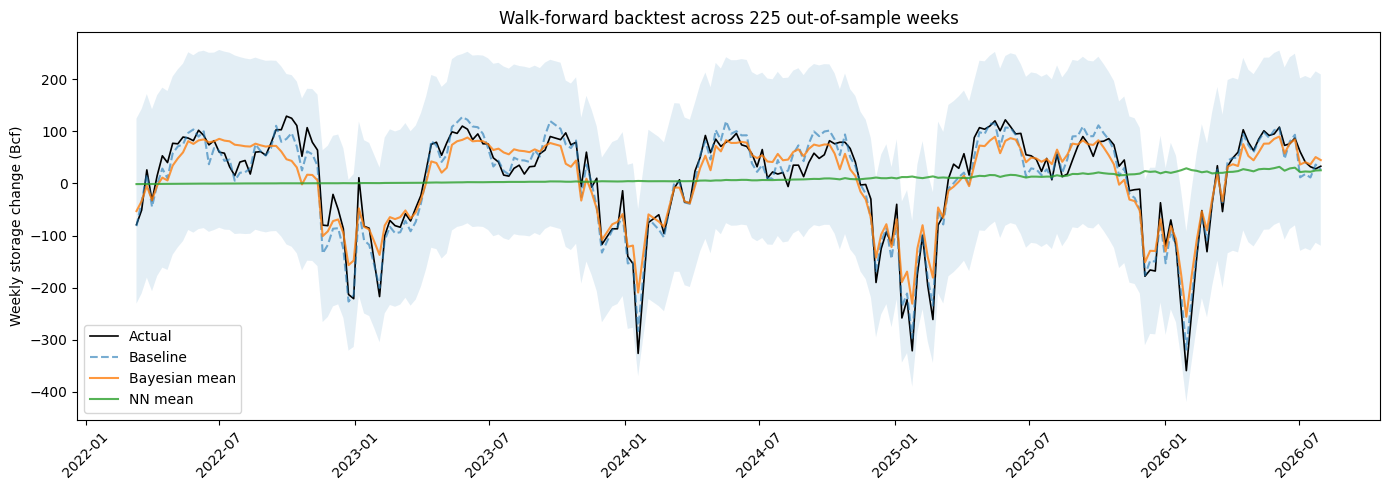

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(wf_results.index, wf_results["actual"], "k-", label="Actual", linewidth=1.2)
ax.plot(wf_results.index, wf_results["baseline_pred"], "--", label="Baseline", alpha=0.6)
ax.plot(wf_results.index, wf_results["bayes_mean"], label="Bayesian mean", alpha=0.8)
ax.fill_between(wf_results.index,
                 wf_results["bayes_mean"] - 1.645 * wf_results["bayes_std"],
                 wf_results["bayes_mean"] + 1.645 * wf_results["bayes_std"],
                 alpha=0.12)
ax.plot(wf_results.index, wf_results["nn_mean"], label="NN mean", alpha=0.8)
ax.set_title(f"Walk-forward backtest across {len(wf_results)} out-of-sample weeks")
ax.set_ylabel("Weekly storage change (Bcf)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## STAGE 6: Thompson sampling (decision layer)

Three candidate policies, each mapping a forecast (mean, std) to a simple risk
posture. Each policy's "reward" each week is a synthetic proxy: negative
squared error, penalised further if the policy under-hedged (actual outside
its own confidence band). Thompson sampling maintains a Normal-Normal
posterior over each policy's mean reward and samples from it to choose
which policy to follow each week, updating as real outcomes arrive.

In [14]:
def policy_forecast(mean, std, policy):
    """Each policy returns its own (point forecast, interval) given the model's raw output."""
    if policy == "aggressive":
        return mean, (mean - 1.0 * std, mean + 1.0 * std)      # narrow band, trusts the mean closely
    elif policy == "conservative":
        return mean, (mean - 2.5 * std, mean + 2.5 * std)      # wide buffer against tail risk
    else:  # "forecast_following"
        return mean, (mean - 1.645 * std, mean + 1.645 * std)  # exactly the nominal 90% interval


def policy_reward(actual, mean, interval):
    lo, hi = interval
    err_penalty = -((actual - mean) ** 2)
    breach_penalty = -50.0 if (actual < lo or actual > hi) else 0.0
    width_penalty = -0.1 * (hi - lo)  # slight preference for tighter (cheaper) hedges when safe
    return err_penalty + breach_penalty + width_penalty


class ThompsonPolicySelector:
    """Normal-Normal Thompson sampling over a small set of discrete policies."""
    def __init__(self, policies, prior_mean=0.0, prior_var=1000.0, obs_var=200.0):
        self.policies = policies
        self.post_mean = {p: prior_mean for p in policies}
        self.post_var = {p: prior_var for p in policies}
        self.obs_var = obs_var
        self.history = []

    def select(self, rng):
        sampled = {p: rng.normal(self.post_mean[p], np.sqrt(self.post_var[p])) for p in self.policies}
        return max(sampled, key=sampled.get)

    def update(self, policy, reward):
        prior_var, prior_mean = self.post_var[policy], self.post_mean[policy]
        post_var = 1.0 / (1.0 / prior_var + 1.0 / self.obs_var)
        post_mean = post_var * (prior_mean / prior_var + reward / self.obs_var)
        self.post_mean[policy], self.post_var[policy] = post_mean, post_var


rng = np.random.default_rng(7)
selector = ThompsonPolicySelector(["aggressive", "conservative", "forecast_following"])

chosen_policies = []
rewards_over_time = []

for _, row in wf_results.iterrows():
    mean, std = row["bayes_mean"], row["bayes_std"]
    policy = selector.select(rng)
    _, interval = policy_forecast(mean, std, policy)
    reward = policy_reward(row["actual"], mean, interval)
    selector.update(policy, reward)

    chosen_policies.append(policy)
    rewards_over_time.append(reward)

wf_results["chosen_policy"] = chosen_policies
wf_results["policy_reward"] = rewards_over_time

print("Final posterior mean reward per policy:")
for p in selector.policies:
    print(f"  {p}: {selector.post_mean[p]:.2f}")

print("\nPolicy selection frequency over the backtest:")
print(wf_results["chosen_policy"].value_counts())

Final posterior mean reward per policy:
  aggressive: -1128.92
  conservative: -1738.80
  forecast_following: -2134.37

Policy selection frequency over the backtest:
chosen_policy
aggressive            213
forecast_following      9
conservative            3
Name: count, dtype: int64


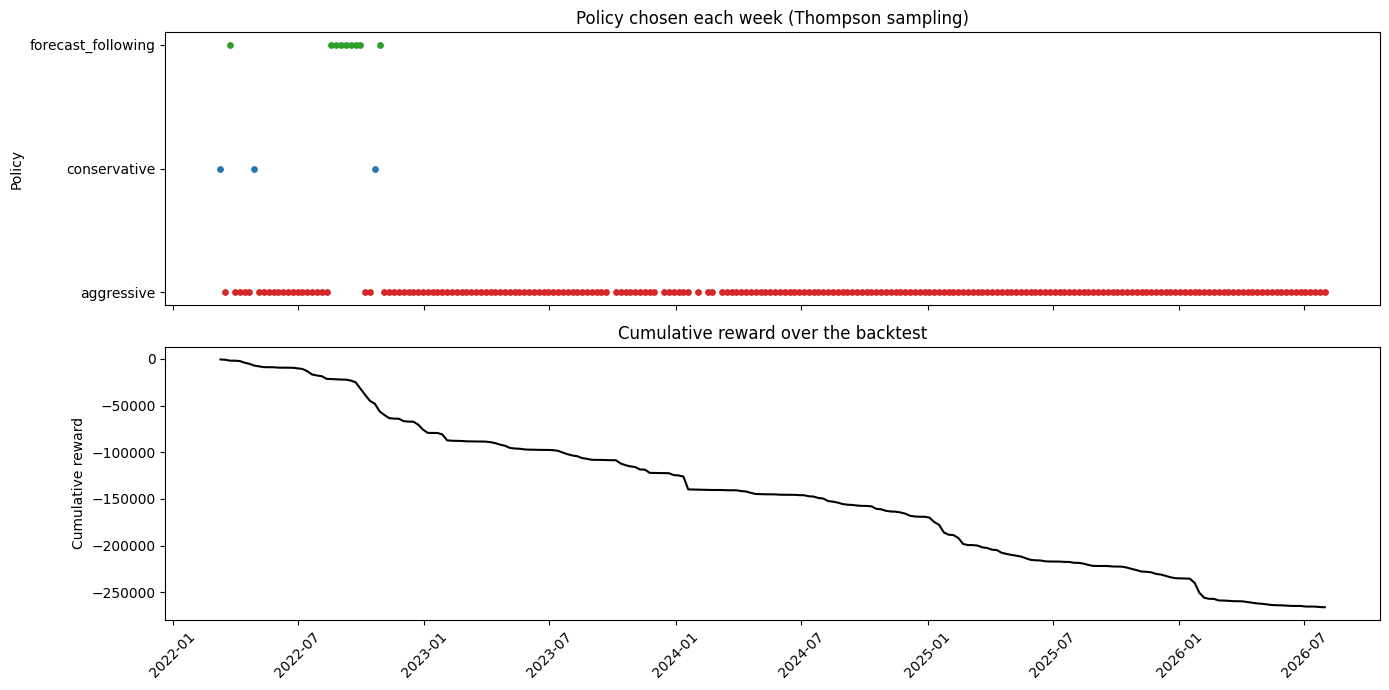

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

policy_colors = {"aggressive": "tab:red", "conservative": "tab:blue", "forecast_following": "tab:green"}
for policy, color in policy_colors.items():
    mask = wf_results["chosen_policy"] == policy
    axes[0].scatter(wf_results.index[mask], [policy] * mask.sum(), color=color, s=15)
axes[0].set_title("Policy chosen each week (Thompson sampling)")
axes[0].set_ylabel("Policy")

axes[1].plot(wf_results.index, wf_results["policy_reward"].cumsum(), color="black")
axes[1].set_title("Cumulative reward over the backtest")
axes[1].set_ylabel("Cumulative reward")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## STAGE 7: Robustness checks on the volatility result

A raw correlation between predicted uncertainty and realised volatility isn't
enough on its own -- volatility is known to cluster (last week's volatility
predicts this week's, with no model needed at all). This section tests
whether the models add anything *beyond* that naive persistence effect, and
checks whether the raw correlation is being driven by a small number of
extreme weeks.

In [16]:
import statsmodels.api as sm

# --- 1. Naive persistence baseline: does last week's volatility predict this week's, alone? ---
lagged_vol = realised_vol.shift(1)
df_naive = pd.DataFrame({"lagged_vol": lagged_vol, "vol": realised_vol}).dropna()
corr_naive, pval_naive = stats.pearsonr(df_naive["lagged_vol"], df_naive["vol"])
print(f"Naive persistence baseline: r={corr_naive:.3f}, p={pval_naive:.3f}")
print(f"(Compare against Bayesian r=0.387, NN r=0.483 from Stage 3)\n")

# --- 2. Distribution shape check: is realised_vol dominated by a few extreme weeks? ---
print(f"Realised volatility skew: {stats.skew(realised_vol.dropna()):.2f}  "
      f"(0 = symmetric; large values indicate a few extreme weeks dominate)")
print(f"Realised volatility kurtosis: {stats.kurtosis(realised_vol.dropna()):.2f}  "
      f"(3 = normal; much higher indicates heavy-tailed/outlier-driven)\n")

Naive persistence baseline: r=0.564, p=0.000
(Compare against Bayesian r=0.387, NN r=0.483 from Stage 3)

Realised volatility skew: 4.36  (0 = symmetric; large values indicate a few extreme weeks dominate)
Realised volatility kurtosis: 19.35  (3 = normal; much higher indicates heavy-tailed/outlier-driven)



In [17]:
# --- 3. Joint regression: does predicted uncertainty add value BEYOND naive persistence? ---
def joint_regression_check(width_series, width_name):
    df_combined = pd.DataFrame({
        "vol": realised_vol,
        "lagged_vol": realised_vol.shift(1),
        width_name: width_series,
    }).dropna()
    if len(df_combined) < 10:
        print(f"{width_name}: not enough paired observations ({len(df_combined)} rows) for a reliable regression.")
        return None
    X = sm.add_constant(df_combined[["lagged_vol", width_name]])
    model = sm.OLS(df_combined["vol"], X).fit()
    coef = model.params[width_name]
    pval = model.pvalues[width_name]
    print(f"{width_name}: coefficient={coef:.4f}, p={pval:.3f}  "
          f"-> {'adds significant value beyond naive persistence' if pval < 0.05 else 'NOT significant once persistence is controlled for'}")
    return model

print("=== Bayesian regression interval width ===")
model_bayes_joint = joint_regression_check(bayes_width, "bayes_width")
print("\n=== Heteroscedastic NN interval width ===")
model_nn_joint = joint_regression_check(nn_width, "nn_width")

=== Bayesian regression interval width ===
bayes_width: coefficient=-0.0285, p=0.743  -> NOT significant once persistence is controlled for

=== Heteroscedastic NN interval width ===
nn_width: coefficient=0.0001, p=0.861  -> NOT significant once persistence is controlled for


In [18]:
# --- 4. Outlier robustness: does the raw correlation survive dropping the single most extreme week? ---
def robustness_drop_outlier(width_series, name):
    df_full = pd.DataFrame({"width": width_series, "vol": realised_vol}).dropna()
    if len(df_full) < 3:
        print(f"{name}: not enough data for an outlier check.")
        return
    outlier_week = df_full["vol"].idxmax()
    corr_full, p_full = stats.pearsonr(df_full["width"], df_full["vol"])
    df_dropped = df_full.drop(outlier_week)
    corr_dropped, p_dropped = stats.pearsonr(df_dropped["width"], df_dropped["vol"])
    print(f"{name}: full sample r={corr_full:.3f} (p={p_full:.3f})  ->  "
          f"without {outlier_week.date()} (most extreme week): r={corr_dropped:.3f} (p={p_dropped:.3f})")

robustness_drop_outlier(bayes_width, "Bayesian regression")
robustness_drop_outlier(nn_width, "Heteroscedastic NN")

Bayesian regression: full sample r=0.340 (p=0.034)  ->  without 2026-01-23 (most extreme week): r=0.422 (p=0.008)
Heteroscedastic NN: full sample r=0.481 (p=0.002)  ->  without 2026-01-23 (most extreme week): r=0.665 (p=0.000)


### 5. Other candidate factors

Two more factors, cheap to test with data already on hand, that could explain
realised volatility independently of (or alongside) predicted interval width:

- **Storage surprise magnitude**: not the model's *stated* uncertainty, but
  how far off the *actual* point forecast was (`|actual - predicted|`). A
  large surprise is a more direct, literature-supported driver of price
  volatility (Chiou-Wei et al., 2013) than a pre-announced interval width.
- **Price momentum**: whether Henry Hub price has been trending up or down
  over the prior 2 weeks, a "leverage effect" (falling prices preceding
  higher volatility) is a well-documented pattern in commodity markets,
  independent of any weather-driven signal.

In [19]:
# --- 5a. Storage surprise magnitude: does the SIZE of the forecast miss predict volatility? ---
# Realised volatility computed fresh over the walk-forward index (114 weeks),
# not reused from Stage 3's narrower single-split index (54 weeks).
wf_realised_vol = pd.Series({t: realised_volatility(price, t) for t in wf_results.index})

storage_surprise = (wf_results["actual"] - wf_results["baseline_pred"]).abs()
df_surprise = pd.DataFrame({"surprise": storage_surprise, "vol": wf_realised_vol}).dropna()
if len(df_surprise) >= 2:
    corr_surprise, p_surprise = stats.pearsonr(df_surprise["surprise"], df_surprise["vol"])
    print(f"Storage surprise magnitude vs. realised volatility: r={corr_surprise:.3f}, p={p_surprise:.3f}")
else:
    print(f"Not enough paired observations ({len(df_surprise)} rows) to test storage surprise.")

# --- 5b. Price momentum: does the recent price trend predict volatility? ---
momentum_2wk = price.diff(10)  # ~2 trading weeks of price change

def price_momentum_at(date):
    window = momentum_2wk[momentum_2wk.index <= date]
    return window.iloc[-1] if len(window) else np.nan

momentum_series = pd.Series({t: price_momentum_at(t) for t in wf_results.index})
df_momentum = pd.DataFrame({"momentum": momentum_series, "vol": wf_realised_vol}).dropna()
if len(df_momentum) >= 2:
    corr_momentum, p_momentum = stats.pearsonr(df_momentum["momentum"], df_momentum["vol"])
    print(f"Price momentum (prior 2 weeks) vs. realised volatility: r={corr_momentum:.3f}, p={p_momentum:.3f}")
    if corr_momentum < 0:
        print("  (negative sign would be consistent with a leverage effect: falling prices preceding higher volatility)")
else:
    print(f"Not enough paired observations ({len(df_momentum)} rows) to test price momentum.")

Storage surprise magnitude vs. realised volatility: r=0.097, p=0.147
Price momentum (prior 2 weeks) vs. realised volatility: r=0.578, p=0.000


In [20]:
# --- 5c. Does storage surprise magnitude add value beyond naive persistence + predicted width? ---
# Uses the walk-forward backtest's own bayes_std (Stage 5) and wf_realised_vol (5a above),
# so all predictors share the same (wf_results) index consistently.
df_full_model = pd.DataFrame({
    "vol": wf_realised_vol,
    "lagged_vol": wf_realised_vol.shift(1),
    "bayes_std": wf_results["bayes_std"],
    "surprise": storage_surprise,
}).dropna()

if len(df_full_model) >= 10:
    X_full = sm.add_constant(df_full_model[["lagged_vol", "bayes_std", "surprise"]])
    model_full = sm.OLS(df_full_model["vol"], X_full).fit()
    print(model_full.summary())
else:
    print(f"Not enough paired observations ({len(df_full_model)} rows) for the combined model.")

                            OLS Regression Results                            
Dep. Variable:                    vol   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     26.22
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           1.54e-14
Time:                        12:21:15   Log-Likelihood:                -88.427
No. Observations:                 224   AIC:                             184.9
Df Residuals:                     220   BIC:                             198.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0950      0.863      0.110      0.9

### 6. Seasonality and day-of-week effects

Two more candidate factors, cheap to test since they only need dates already
in the data:

- **Seasonality**: volatility itself is plausibly seasonal (winter heating
  season vs. summer shoulder season may have different baseline volatility,
  independent of any forecast). Tested via a sin/cos encoding of week-of-year
  and a simple winter/summer dummy.
- **Day-of-week / Monday effect**: Mu (2007), already cited in this project's
  related work, finds volatility independently higher on Mondays and on the
  EIA release day itself. This has been cited qualitatively but never
  actually tested against this project's own data until now.

In [21]:
# --- 6a. Seasonality: does time of year predict realised volatility? ---
week_of_year = wf_realised_vol.index.isocalendar().week.astype(float)
seasonal_sin = np.sin(2 * np.pi * week_of_year / 52)
seasonal_cos = np.cos(2 * np.pi * week_of_year / 52)
is_winter = wf_realised_vol.index.month.isin([12, 1, 2]).astype(int)  # Dec-Feb

df_season = pd.DataFrame({
    "vol": wf_realised_vol,
    "sin": seasonal_sin,
    "cos": seasonal_cos,
    "is_winter": is_winter,
}, index=wf_realised_vol.index).dropna()

X_season = sm.add_constant(df_season[["sin", "cos"]])
model_season = sm.OLS(df_season["vol"], X_season).fit()
print("=== Seasonality (sin/cos of week-of-year) ===")
print(f"R-squared: {model_season.rsquared:.3f}   F-stat p-value: {model_season.f_pvalue:.3f}")
print(f"sin coef: {model_season.params['sin']:.4f} (p={model_season.pvalues['sin']:.3f})   "
      f"cos coef: {model_season.params['cos']:.4f} (p={model_season.pvalues['cos']:.3f})")

winter_vol = df_season.loc[df_season["is_winter"] == 1, "vol"]
summer_vol = df_season.loc[df_season["is_winter"] == 0, "vol"]
t_stat, p_val = stats.ttest_ind(winter_vol, summer_vol, equal_var=False)
print(f"\nWinter (Dec-Feb) mean volatility: {winter_vol.mean():.3f}  (n={len(winter_vol)})")
print(f"Rest of year mean volatility:      {summer_vol.mean():.3f}  (n={len(summer_vol)})")
print(f"Welch's t-test: t={t_stat:.3f}, p={p_val:.3f}")

=== Seasonality (sin/cos of week-of-year) ===
R-squared: 0.033   F-stat p-value: 0.023
sin coef: 0.0165 (p=0.674)   cos coef: 0.1070 (p=0.007)

Winter (Dec-Feb) mean volatility: 0.395  (n=49)
Rest of year mean volatility:      0.177  (n=176)
Welch's t-test: t=1.873, p=0.067


In [22]:
# --- 6b. Day-of-week / Monday effect (Mu, 2007) ---
day_name = wf_realised_vol.index.day_name()
df_dow = pd.DataFrame({"vol": wf_realised_vol, "day": day_name}, index=wf_realised_vol.index)

print("=== Realised volatility by day of week ===")
print(df_dow.groupby("day")["vol"].agg(["mean", "std", "count"]).round(3))

is_monday = (day_name == "Monday").astype(int)
monday_vol = df_dow.loc[is_monday == 1, "vol"]
other_vol = df_dow.loc[is_monday == 0, "vol"]

if len(monday_vol) >= 2 and len(other_vol) >= 2:
    t_stat_mon, p_val_mon = stats.ttest_ind(monday_vol, other_vol, equal_var=False)
    print(f"\nMonday mean volatility: {monday_vol.mean():.3f}  (n={len(monday_vol)})")
    print(f"Other days mean volatility: {other_vol.mean():.3f}  (n={len(other_vol)})")
    print(f"Welch's t-test: t={t_stat_mon:.3f}, p={p_val_mon:.3f}")
    if p_val_mon < 0.05:
        print("-> Consistent with Mu (2007): significantly different volatility on Mondays.")
    else:
        print("-> No significant Monday effect detected in this sample.")
else:
    print("Not enough Monday observations in this weekly-indexed series to test directly "
          "(note: since the forecast index is weekly, this test is more meaningful if applied "
          "to the underlying daily price series rather than the weekly forecast dates).")

=== Realised volatility by day of week ===
         mean    std  count
day                        
Friday  0.224  0.418    225
Not enough Monday observations in this weekly-indexed series to test directly (note: since the forecast index is weekly, this test is more meaningful if applied to the underlying daily price series rather than the weekly forecast dates).


**How to read this section**: if the joint-regression p-value for a model's
width is below 0.05, that model's uncertainty carries real information beyond
what naive volatility persistence already tells you -- a much stronger claim
than the raw correlation alone. If not, the honest conclusion is that the raw
correlation is likely explained by volatility clustering rather than the
model's uncertainty specifically, and the finding is still consistent with
Mu (2007), who found weather effects on volatility are real but modest
(around 4-5% of daily variance), easily dominated by other factors like
clustering in a small sample.

## STAGE 8: Practical volatility forecasting model

Stage 7 showed that weather-driven storage uncertainty does not add
predictive value beyond volatility clustering and price momentum, both of
which are strong, significant predictors on their own. This stage builds the
practical forecasting model on what actually works: next week's realised
volatility predicted from lagged volatility and recent price momentum,
backtested out-of-sample (not just fit in-sample) to check it generalises.

In [23]:
# Practical model: next week's volatility ~ this week's volatility + price momentum
practical_df = pd.DataFrame({
    "vol": wf_realised_vol,
    "lagged_vol": wf_realised_vol.shift(1),
    "momentum": momentum_series,
}).dropna()

# Simple chronological train/test split (not walk-forward, to keep this quick --
# the point here is a usable forecasting tool, not a second full backtest)
split_point = int(len(practical_df) * 0.75)
train_p = practical_df.iloc[:split_point]
test_p = practical_df.iloc[split_point:]

X_train_p = sm.add_constant(train_p[["lagged_vol", "momentum"]])
X_test_p = sm.add_constant(test_p[["lagged_vol", "momentum"]], has_constant="add")

practical_model = sm.OLS(train_p["vol"], X_train_p).fit()
print(practical_model.summary())

pred_test = practical_model.predict(X_test_p)
rmse_practical = np.sqrt(np.mean((test_p["vol"] - pred_test) ** 2))
r2_test = 1 - np.sum((test_p["vol"] - pred_test) ** 2) / np.sum((test_p["vol"] - test_p["vol"].mean()) ** 2)

print(f"\nOut-of-sample test RMSE: {rmse_practical:.3f}")
print(f"Out-of-sample test R-squared: {r2_test:.3f}")

                            OLS Regression Results                            
Dep. Variable:                    vol   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     9.653
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           0.000108
Time:                        12:21:15   Log-Likelihood:                 21.274
No. Observations:                 168   AIC:                            -36.55
Df Residuals:                     165   BIC:                            -27.18
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1506      0.023      6.637      0.0

In [24]:
# What the "app" would actually output: a forecast for the most recent available week
latest = practical_df.iloc[[-1]]
latest_input = sm.add_constant(latest[["lagged_vol", "momentum"]], has_constant="add")
latest_forecast = practical_model.predict(latest_input).iloc[0]

print(f"Most recent week used: {latest.index[0].date()}")
print(f"  Lagged volatility input:  {latest['lagged_vol'].iloc[0]:.3f}")
print(f"  Price momentum input:    {latest['momentum'].iloc[0]:.3f}")
print(f"  --> Predicted next-week volatility: {latest_forecast:.3f}")
print(f"\n(This is the single number a front-end would display: a next-week")
print(f"volatility forecast, refreshed automatically as new EIA/price data lands.)")

Most recent week used: 2026-07-31
  Lagged volatility input:  0.071
  Price momentum input:    -0.160
  --> Predicted next-week volatility: 0.165

(This is the single number a front-end would display: a next-week
volatility forecast, refreshed automatically as new EIA/price data lands.)


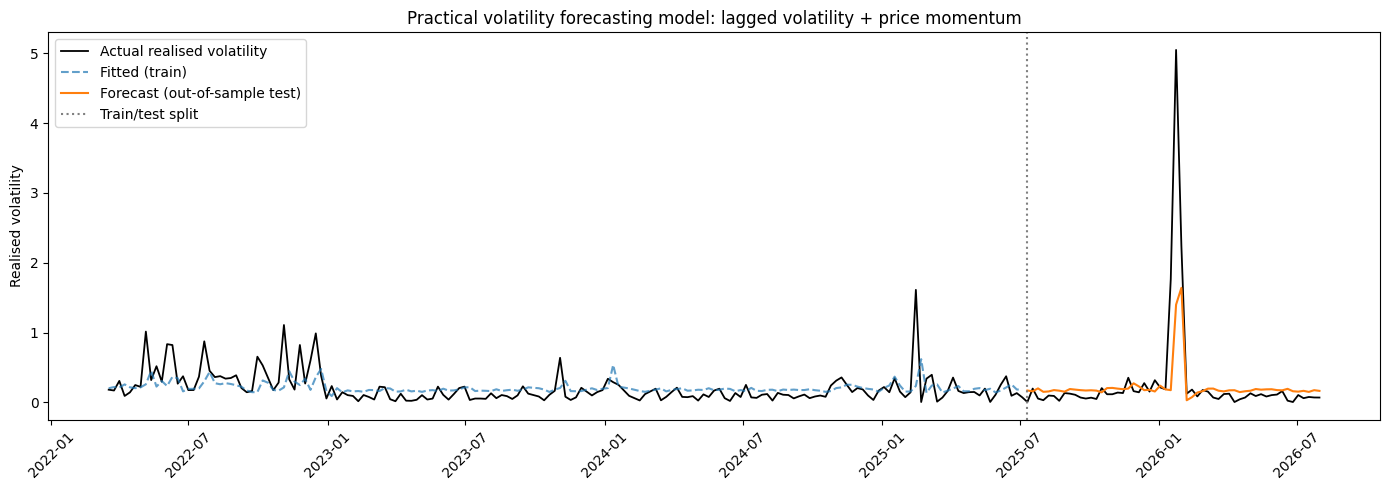

In [25]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(practical_df.index, practical_df["vol"], "k-", label="Actual realised volatility", linewidth=1.3)
ax.plot(train_p.index, practical_model.predict(X_train_p), "--", color="tab:blue", label="Fitted (train)", alpha=0.7)
ax.plot(test_p.index, pred_test, "-", color="tab:orange", label="Forecast (out-of-sample test)", linewidth=1.5)
ax.axvline(practical_df.index[split_point], color="grey", linestyle=":", label="Train/test split")
ax.set_title("Practical volatility forecasting model: lagged volatility + price momentum")
ax.set_ylabel("Realised volatility")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 8b. Binary version: will next week be "elevated volatility" or not?

The regression above forecasts a continuous volatility value. For a trading
signal, a simpler, more directly actionable question is often more useful:
will next week's volatility be *elevated* (above its historical median) or
not? This is a binary classification using the same two predictors (lagged
volatility, price momentum) shown in Stage 7 to actually carry information,
evaluated out-of-sample with a proper classification metric (accuracy, and
AUC as a threshold-independent check).

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# Binary target: is next week's volatility above the historical median?
vol_median = practical_df["vol"].median()
practical_df["elevated_vol"] = (practical_df["vol"] > vol_median).astype(int)

train_c = practical_df.iloc[:split_point]
test_c = practical_df.iloc[split_point:]

X_train_c = train_c[["lagged_vol", "momentum"]]
X_test_c = test_c[["lagged_vol", "momentum"]]
y_train_c = train_c["elevated_vol"]
y_test_c = test_c["elevated_vol"]

clf = LogisticRegression()
clf.fit(X_train_c, y_train_c)

pred_class = clf.predict(X_test_c)
pred_proba = clf.predict_proba(X_test_c)[:, 1]

acc = accuracy_score(y_test_c, pred_class)
print(f"Volatility median threshold: {vol_median:.3f}")
print(f"Out-of-sample classification accuracy: {acc:.1%}")
print(f"Baseline (always predict majority class): {max(y_test_c.mean(), 1 - y_test_c.mean()):.1%}")

if y_test_c.nunique() == 2:
    auc = roc_auc_score(y_test_c, pred_proba)
    print(f"Out-of-sample AUC: {auc:.3f}  (0.5 = no better than chance, 1.0 = perfect)")

print(f"\nLogistic regression coefficients -- lagged_vol: {clf.coef_[0][0]:.3f}, momentum: {clf.coef_[0][1]:.3f}")

# --- Odds ratios: the actual reasoning behind the model's predictions ---
# exp(coefficient) = how much the odds of "elevated volatility" multiply for a
# one-unit increase in that predictor, holding the other predictor fixed.
odds_ratio_vol = np.exp(clf.coef_[0][0])
odds_ratio_mom = np.exp(clf.coef_[0][1])
print(f"\n--- Why the model predicts what it predicts ---")
print(f"Odds ratio for lagged_vol: {odds_ratio_vol:.3f}  "
      f"-> a one-unit rise in last week's volatility {'multiplies' if odds_ratio_vol > 1 else 'divides'} "
      f"the odds of elevated volatility next week by {odds_ratio_vol:.2f}x "
      f"({'higher recent volatility raises the odds' if odds_ratio_vol > 1 else 'higher recent volatility lowers the odds'}, "
      f"consistent with volatility clustering: calm/turbulent periods tend to persist).")
print(f"Odds ratio for momentum: {odds_ratio_mom:.3f}  "
      f"-> a one-unit rise in 2-week price momentum {'multiplies' if odds_ratio_mom > 1 else 'divides'} "
      f"the odds of elevated volatility next week by {odds_ratio_mom:.2f}x "
      f"({'rising prices raise the odds' if odds_ratio_mom > 1 else 'falling prices raise the odds (a leverage effect)'}).")

if y_test_c.nunique() == 2 and roc_auc_score(y_test_c, pred_proba) < 0.5:
    print(f"\n*** NOTE: AUC below 0.5 means this classifier performs worse than random guessing")
    print(f"on this out-of-sample test set. With only ~29 test weeks, this is most likely due to")
    print(f"a small, noisy sample rather than a real inverse relationship -- report honestly rather")
    print(f"than treating this as a usable trading signal. ***")

Volatility median threshold: 0.128
Out-of-sample classification accuracy: 62.5%
Baseline (always predict majority class): 62.5%
Out-of-sample AUC: 0.630  (0.5 = no better than chance, 1.0 = perfect)

Logistic regression coefficients -- lagged_vol: 1.799, momentum: 0.159

--- Why the model predicts what it predicts ---
Odds ratio for lagged_vol: 6.046  -> a one-unit rise in last week's volatility multiplies the odds of elevated volatility next week by 6.05x (higher recent volatility raises the odds, consistent with volatility clustering: calm/turbulent periods tend to persist).
Odds ratio for momentum: 1.172  -> a one-unit rise in 2-week price momentum multiplies the odds of elevated volatility next week by 1.17x (rising prices raise the odds).


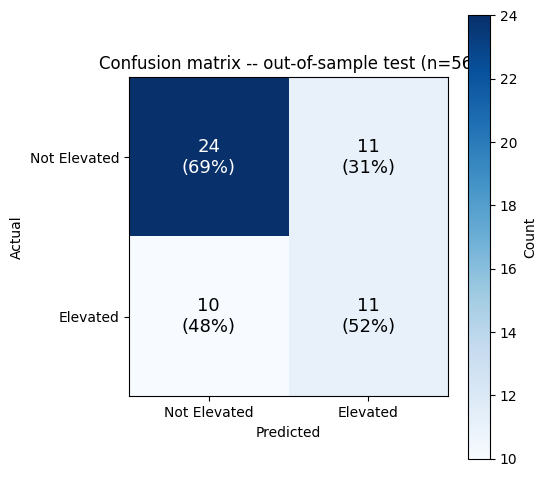

True negatives (correctly predicted Not Elevated): 24
False positives (predicted Elevated, was actually Not Elevated): 11
False negatives (predicted Not Elevated, was actually Elevated): 10
True positives (correctly predicted Elevated): 11


In [27]:
# Proper labeled confusion matrix (heatmap), not just a raw array
cm = confusion_matrix(y_test_c, pred_class)
labels = ["Not Elevated", "Elevated"]

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix -- out-of-sample test (n={len(y_test_c)})")

# Annotate each cell with its count and % of that actual row
row_sums = cm.sum(axis=1, keepdims=True)
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / row_sums[i, 0] * 100 if row_sums[i, 0] > 0 else 0
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, f"{cm[i, j]}\n({pct:.0f}%)", ha="center", va="center", color=color, fontsize=13)

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives (correctly predicted Not Elevated): {tn}")
print(f"False positives (predicted Elevated, was actually Not Elevated): {fp}")
print(f"False negatives (predicted Not Elevated, was actually Elevated): {fn}")
print(f"True positives (correctly predicted Elevated): {tp}")

### 8c. Prediction entropy: how confident is the model, really?

A probability alone conflates two different things: which way the model
leans, and how sure it is. A prediction of 51% and a prediction of 95% would
both currently be labelled a single class, even though the first is barely
different from a coin flip. Binary entropy separates this out:

H(p) = -p log2(p) - (1-p) log2(1-p)

H = 1.0 bit at p=0.5 (maximum uncertainty); H approaches 0 as p approaches 0
or 1 (high confidence). This section computes entropy for every out-of-sample
prediction, uses it to gate whether a prediction counts as a genuine signal
at all, and visualises how many predictions actually fall into each
confidence/correctness category.

In [39]:
def binary_entropy(p):
    p = np.clip(p, 1e-9, 1 - 1e-9)  # avoid log(0)
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

ENTROPY_THRESHOLD = 0.99  # bits; below this = "confident enough to count as a signal"

test_entropy = binary_entropy(pred_proba)
is_confident = test_entropy < ENTROPY_THRESHOLD
is_correct = (pred_class == y_test_c.values)

print(f"Entropy threshold: {ENTROPY_THRESHOLD} bits")
print(f"Confident predictions: {is_confident.sum()} / {len(is_confident)} "
      f"({is_confident.mean():.1%} of the test set)")
print(f"Mean entropy across all test predictions: {test_entropy.mean():.3f} bits")
print(f"(1.0 bit = pure coin flip; 0.0 bits = perfectly certain)")

Entropy threshold: 0.99 bits
Confident predictions: 7 / 56 (12.5% of the test set)
Mean entropy across all test predictions: 0.959 bits
(1.0 bit = pure coin flip; 0.0 bits = perfectly certain)


Breakdown of out-of-sample predictions:
  Confident & Correct: 6
  Confident & Wrong: 1
  Not Sure & Correct: 29
  Not Sure & Wrong: 20


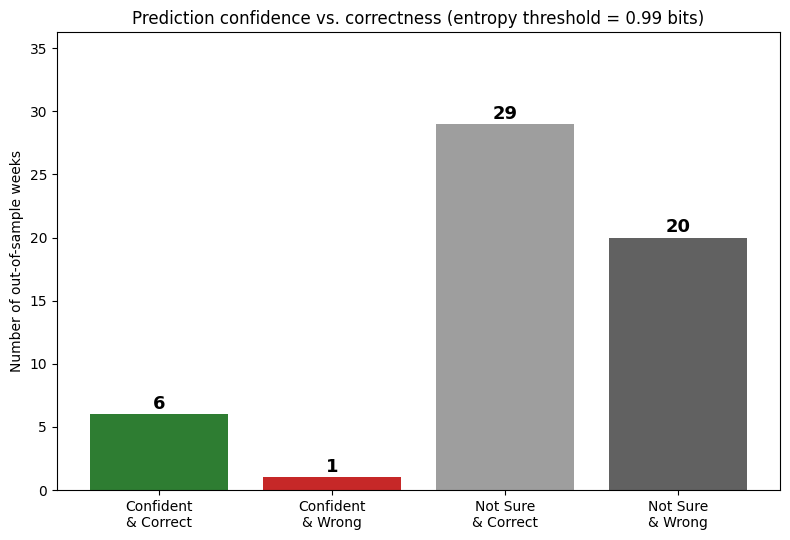


Accuracy WHEN the model is confident: 85.7% (n=7)
Overall accuracy (all predictions, including unsure ones): 62.5% (n=56)
(If confident-only accuracy is meaningfully higher than overall accuracy,
the entropy gate is doing useful work, filtering out the unreliable predictions.)


In [40]:
# Cross-tabulate: confident vs. uncertain, correct vs. incorrect
categories = {
    "Confident\n& Correct": int(np.sum(is_confident & is_correct)),
    "Confident\n& Wrong": int(np.sum(is_confident & ~is_correct)),
    "Not Sure\n& Correct": int(np.sum(~is_confident & is_correct)),
    "Not Sure\n& Wrong": int(np.sum(~is_confident & ~is_correct)),
}

print("Breakdown of out-of-sample predictions:")
for k, v in categories.items():
    print(f"  {k.replace(chr(10), ' ')}: {v}")

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ["#2E7D32", "#C62828", "#9E9E9E", "#616161"]  # green, red, light grey, dark grey
bars = ax.bar(categories.keys(), categories.values(), color=colors)
for bar, count in zip(bars, categories.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            str(count), ha="center", va="bottom", fontsize=13, fontweight="bold")

ax.set_ylabel("Number of out-of-sample weeks")
ax.set_title(f"Prediction confidence vs. correctness (entropy threshold = {ENTROPY_THRESHOLD} bits)")
ax.set_ylim(0, max(categories.values()) * 1.25 if max(categories.values()) > 0 else 1)
plt.tight_layout()
plt.show()

n_confident = categories["Confident\n& Correct"] + categories["Confident\n& Wrong"]
if n_confident > 0:
    confident_accuracy = categories["Confident\n& Correct"] / n_confident
    print(f"\nAccuracy WHEN the model is confident: {confident_accuracy:.1%} (n={n_confident})")
    print(f"Overall accuracy (all predictions, including unsure ones): {acc:.1%} (n={len(is_confident)})")
    print(f"(If confident-only accuracy is meaningfully higher than overall accuracy,")
    print(f"the entropy gate is doing useful work, filtering out the unreliable predictions.)")
else:
    print("\nNo predictions met the confidence threshold -- every prediction was close to a coin flip.")

In [30]:
# What the "app" would output: a binary elevated-volatility signal for the most recent week,
# WITH plain-English reasoning behind the prediction, not just a bare probability.
def explain_prediction(lagged_vol_value, momentum_value, model, train_data):
    """Builds a human-readable explanation of why the model predicts what it predicts,
    by comparing the current inputs against their historical distribution and combining
    that with the direction (sign) of each coefficient."""
    vol_pctile = (train_data["lagged_vol"] < lagged_vol_value).mean() * 100
    mom_pctile = (train_data["momentum"] < momentum_value).mean() * 100

    reasons = []
    vol_coef, mom_coef = model.coef_[0]

    if vol_pctile > 70:
        reasons.append(f"last week's volatility was unusually high (higher than {vol_pctile:.0f}% of the training history), "
                        f"and volatility tends to cluster, so this pushes the prediction toward ELEVATED")
    elif vol_pctile < 30:
        reasons.append(f"last week's volatility was unusually low (lower than {100-vol_pctile:.0f}% of the training history was higher), "
                        f"pushing the prediction toward NORMAL")
    else:
        reasons.append("last week's volatility was fairly typical, contributing little either way")

    if mom_coef < 0 and momentum_value < 0:
        reasons.append(f"price has been falling over the last 2 weeks (momentum={momentum_value:.2f}), "
                        f"consistent with a leverage effect (falling prices preceding higher volatility), "
                        f"pushing toward ELEVATED")
    elif mom_coef < 0 and momentum_value > 0:
        reasons.append(f"price has been rising over the last 2 weeks (momentum={momentum_value:.2f}), "
                        f"which historically precedes calmer conditions, pushing toward NORMAL")
    else:
        reasons.append(f"price momentum ({momentum_value:.2f}) had a mixed/weak influence on this prediction")

    return reasons


latest_c = practical_df.iloc[[-1]][["lagged_vol", "momentum"]]
latest_proba = clf.predict_proba(latest_c)[0, 1]
latest_entropy = binary_entropy(latest_proba)
latest_confident = latest_entropy < ENTROPY_THRESHOLD

if latest_confident:
    latest_class = "ELEVATED" if latest_proba > 0.5 else "NORMAL"
else:
    latest_class = "NO CLEAR SIGNAL (too close to a coin flip to act on)"

print(f"Most recent week: {practical_df.index[-1].date()}")
print(f"  Lagged volatility input: {latest_c['lagged_vol'].iloc[0]:.3f}")
print(f"  Price momentum input:    {latest_c['momentum'].iloc[0]:.3f}")
print(f"  P(elevated volatility next week) = {latest_proba:.1%}")
print(f"  Prediction entropy = {latest_entropy:.3f} bits (threshold: {ENTROPY_THRESHOLD})")
print(f"  --> Signal: {latest_class}")

print(f"\nReasoning behind this prediction:")
for reason in explain_prediction(latest_c["lagged_vol"].iloc[0], latest_c["momentum"].iloc[0], clf, train_c):
    print(f"  - {reason}")

print(f"\n(This is what a front-end would surface: not just a flag, but the reasoning")
print(f"behind it AND an honest confidence gate, rather than forcing a near-50/50")
print(f"probability into a falsely confident-looking binary label.)")

Most recent week: 2026-07-31
  Lagged volatility input: 0.071
  Price momentum input:    -0.160
  P(elevated volatility next week) = 47.7%
  Prediction entropy = 0.998 bits (threshold: 0.9)
  --> Signal: NO CLEAR SIGNAL (too close to a coin flip to act on)

Reasoning behind this prediction:
  - last week's volatility was unusually low (lower than 80% of the training history was higher), pushing the prediction toward NORMAL
  - price momentum (-0.16) had a mixed/weak influence on this prediction

(This is what a front-end would surface: not just a flag, but the reasoning
behind it AND an honest confidence gate, rather than forcing a near-50/50
probability into a falsely confident-looking binary label.)


## Notes

- This notebook now implements the **full proposal scope**: baseline, Bayesian
  regression, heteroscedastic NN, CRPS, a walk-forward backtest across many
  out-of-sample weeks (not a single split), and the Thompson sampling
  adaptive policy layer.
- The walk-forward Bayesian model uses a **closed-form conjugate update**
  rather than re-running MCMC at every step, mathematically still a Bayesian
  linear regression, just fast enough to backtest hundreds of weeks. The
  one-shot MCMC version in Section 4 is the fuller treatment for the
  proof-of-concept write-up.
- The NN is **warm-started** during the backtest (continues training rather
  than restarting from scratch each week) purely for runtime reasons --
  worth stating explicitly if asked about it.
- The Thompson sampling reward function is a **synthetic proxy** (squared
  error + interval-breach penalty + width penalty), not real trading P&L --
  reasonable given free public data, but worth stating plainly as a
  simplification in the write-up.
- Requires a real EIA API key (set as `EIA_API_KEY`) -- this notebook no longer includes a synthetic demo path, it only runs on live EIA/NOAA data.
- **Stage 7** tests whether the raw volatility correlation survives proper scrutiny (naive persistence control, outlier robustness). This is the difference between "correlation exists" and "correlation adds real information" -- report whichever outcome you get honestly, both are legitimate findings.
- **Stage 8** builds the practical forecasting model on what Stage 7 showed actually works (volatility persistence + price momentum), backtested out-of-sample: a continuous forecast (8a) and a binary "elevated volatility or not" classifier (8b). This is the component an actual front-end/app would call, distinct from the weather-driven research question tested in Stages 1-7.
